# RAFT Fine-Tuning dengan Unsloth — Versi Diperbaiki

Notebook ini menyesuaikan pipeline dengan skema dataset aktual:

- **Dataset fine-tuning:** `instruction`, `documents`, `thought_process`, `completion`
- **Dataset tes:** `message`, `ground_truth`, dan metadata
- **Evaluasi utama:** RAFT/open-book — pertanyaan → retrieval dokumen → model
- **Evaluasi tambahan:** closed-book opsional untuk melihat pengetahuan yang terserap ke bobot LoRA

Perbaikan penting:

1. Mendeteksi dan mengeluarkan pertanyaan tes yang bocor ke training.
2. Menggunakan format **conversational prompt–completion** sehingga loss hanya pada jawaban model.
3. Menggunakan chat template tokenizer, bukan merakit token khusus Llama secara manual.
4. Mengubah `thought_process` menjadi keluaran RAFT terstruktur: konteks terpilih, konteks ditolak, bukti kutipan, dan jawaban.
5. Menambahkan retriever TF-IDF untuk menguji data tes yang tidak memiliki kolom dokumen.
6. Membandingkan hasil **sebelum** dan **sesudah** fine-tuning.
7. Menyatukan seluruh path output agar tidak terjadi salah versi model/adaptor.

> Catatan: data tes yang diberikan ternyata identik dengan sebagian pertanyaan dataset fine-tuning. Notebook ini otomatis menahan semua pertanyaan tersebut sebagai **holdout test** agar evaluasi tidak palsu.

In [1]:
# Jalankan hanya bila environment belum memiliki dependensi.
# Setelah instalasi, restart kernel lalu jalankan notebook dari awal.

# %pip install -U unsloth unsloth_zoo
# %pip install -U transformers trl peft accelerate bitsandbytes datasets
# %pip install -U scikit-learn pandas matplotlib tqdm

## 1. Konfigurasi

In [ ]:
from pathlib import Path
import os


def first_existing(candidates, kind="file"):
    for candidate in candidates:
        p = Path(candidate).expanduser().resolve()
        if kind == "file" and p.is_file():
            return p
        if kind == "dir" and p.is_dir():
            return p
    return None

# Path dapat dioverride dengan environment variable.
RAFT_DATA_PATH = Path(os.environ["RAFT_DATA_PATH"]).expanduser() if "RAFT_DATA_PATH" in os.environ else first_existing([
    "/workspace/data/dataset/raft_dataset_finalv3.jsonl",
    "/workspace/data/raft_dataset_finalv3.jsonl",
    "../data/dataset/raft_dataset_finalv3.jsonl",
    "./raft_dataset_finalv3.jsonl",
    "/mnt/data/raft_dataset_finalv3.jsonl",
])

TEST_DATA_PATH = Path(os.environ["RAFT_TEST_DATA_PATH"]).expanduser() if "RAFT_TEST_DATA_PATH" in os.environ else first_existing([
    "/workspace/data/dataset/test_dataset_.json",
    "/workspace/data/test_dataset_.json",
    "../data/dataset/test_dataset_.json",
    "./test_dataset_.json",
    "/mnt/data/test_dataset_.json",
])

local_model = first_existing([
    "/workspace/model/Meta-Llama-3.1-8B-Instruct",
    "../model/Meta-Llama-3.1-8B-Instruct",
    "./Meta-Llama-3.1-8B-Instruct",
], kind="dir")

MODEL_NAME = os.environ.get(
    "RAFT_MODEL_NAME",
    str(local_model) if local_model else "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
)

OUTPUT_ROOT = Path(os.environ.get(
    "RAFT_OUTPUT_DIR",
    "/workspace/model/raft_unsloth_v8" if Path("/workspace/model").is_dir() else "./raft_unsloth_v8",
)).expanduser().resolve()

ADAPTER_DIR = OUTPUT_ROOT / "lora_adapter"
MERGED_DIR = OUTPUT_ROOT / "merged_16bit"
RESULTS_DIR = OUTPUT_ROOT / "evaluation"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"

# Model & training
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = True          # QLoRA: jauh lebih hemat VRAM
LORA_R = 16
LORA_ALPHA = 32
SEED = 3407
VALIDATION_RATIO = 0.10
NUM_TRAIN_EPOCHS = 3
TRAIN_BATCH_SIZE = 1         # aman untuk 8B + konteks panjang
GRADIENT_ACCUMULATION = 16   # effective batch = 16
LEARNING_RATE = 1e-4

# RAFT
TOP_K_RETRIEVAL = 5
NO_ORACLE_AUGMENT_RATIO = 0.15  # 0.0 untuk mematikan augmentasi no-oracle

# Evaluasi
RUN_BASELINE_EVAL = True
RUN_CLOSED_BOOK_EVAL = False    # lebih mahal; aktifkan untuk uji memorisasi
MAX_NEW_TOKENS = 4096

# Penyimpanan
SAVE_MERGED_16BIT = False       # butuh ruang disk/RAM besar

assert RAFT_DATA_PATH and RAFT_DATA_PATH.is_file(), f"Dataset RAFT tidak ditemukan: {RAFT_DATA_PATH}"
assert TEST_DATA_PATH and TEST_DATA_PATH.is_file(), f"Dataset tes tidak ditemukan: {TEST_DATA_PATH}"

for d in [OUTPUT_ROOT, ADAPTER_DIR, RESULTS_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("RAFT dataset :", RAFT_DATA_PATH)
print("Test dataset :", TEST_DATA_PATH)
print("Base model   :", MODEL_NAME)
print("Output       :", OUTPUT_ROOT)

RAFT dataset : /workspace/data/dataset/raft_dataset_finalv3.jsonl
Test dataset : /workspace/data/test_dataset_.json
Base model   : /workspace/model/Meta-Llama-3.1-8B-Instruct
Output       : /workspace/model/raft_unsloth_v8


## 2. Import, seed, dan pemeriksaan GPU

In [3]:
import gc
import json
import math
import random
import re
import unicodedata
import inspect
from collections import Counter

import numpy as np
import pandas as pd
import torch
import transformers
import trl
from datasets import Dataset
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("TRL         :", trl.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {torch.cuda.get_device_name(i)} | {props.total_memory / 1024**3:.2f} GB")

assert torch.cuda.is_available(), "Fine-tuning model 8B dengan notebook ini membutuhkan GPU CUDA."

/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.11.0+cu128
Transformers: 5.5.0
TRL         : 0.24.0
CUDA        : True
GPU 0: NVIDIA B200 | 178.36 GB


## 3. Memuat dan memvalidasi kedua dataset

In [4]:
def load_jsonl(path):
    rows = []
    with Path(path).open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSONL rusak pada baris {line_number}: {exc}") from exc
    return rows


def validate_raft_row(row, index):
    required = {"instruction", "documents", "thought_process", "completion"}
    missing = required - set(row)
    assert not missing, f"Baris RAFT {index} kehilangan kolom: {missing}"
    assert isinstance(row["instruction"], str) and row["instruction"].strip()
    assert isinstance(row["documents"], list) and row["documents"]
    assert all(isinstance(doc, str) and doc.strip() for doc in row["documents"])
    assert isinstance(row["completion"], str) and row["completion"].strip()
    assert isinstance(row["thought_process"], (dict, str))


def validate_test_row(row, index):
    required = {"message", "ground_truth"}
    missing = required - set(row)
    assert not missing, f"Baris test {index} kehilangan kolom: {missing}"
    assert isinstance(row["message"], str) and row["message"].strip()
    assert isinstance(row["ground_truth"], str) and row["ground_truth"].strip()


raft_rows_all = load_jsonl(RAFT_DATA_PATH)
with Path(TEST_DATA_PATH).open("r", encoding="utf-8") as f:
    test_rows = json.load(f)

assert isinstance(test_rows, list), "Dataset tes harus berupa JSON array/list."

for i, row in enumerate(raft_rows_all):
    validate_raft_row(row, i)
for i, row in enumerate(test_rows):
    validate_test_row(row, i)

print(f"RAFT rows : {len(raft_rows_all)}")
print(f"Test rows : {len(test_rows)}")
print("Kolom RAFT:", sorted(raft_rows_all[0].keys()))
print("Kolom test:", sorted(test_rows[0].keys()))
print("Distribusi jumlah dokumen:", Counter(len(r["documents"]) for r in raft_rows_all))

RAFT rows : 403
Test rows : 41
Kolom RAFT: ['completion', 'documents', 'instruction', 'thought_process']
Kolom test: ['evaluate', 'ground_truth', 'message', 'model_id', 'session_id', 'user_id']
Distribusi jumlah dokumen: Counter({5: 276, 4: 71, 3: 48, 2: 7, 1: 1})


## 4. Mencegah data leakage dari test ke training

In [5]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return " ".join(text.split())


test_question_norms = {normalize_text(row["message"]) for row in test_rows}
leaked_rows = [
    row for row in raft_rows_all
    if normalize_text(row["instruction"]) in test_question_norms
]

# Pertanyaan test dikeluarkan dari supervised fine-tuning.
raft_rows_trainable = [
    row for row in raft_rows_all
    if normalize_text(row["instruction"]) not in test_question_norms
]

print(f"Pertanyaan test yang ditemukan di dataset RAFT: {len(leaked_rows)} / {len(test_rows)}")
print(f"Baris tersisa untuk train/validation         : {len(raft_rows_trainable)}")

assert len(leaked_rows) == len(test_rows), (
    "Jumlah overlap berubah dari audit awal. Periksa apakah dataset telah dimodifikasi."
)
assert raft_rows_trainable, "Tidak ada baris tersisa untuk training."

leakage_report = pd.DataFrame({
    "test_question": [row["message"] for row in test_rows],
    "exists_in_raw_finetune": [
        normalize_text(row["message"]) in {
            normalize_text(r["instruction"]) for r in raft_rows_all
        }
        for row in test_rows
    ],
})
leakage_report.to_csv(RESULTS_DIR / "data_leakage_report.csv", index=False)
display(leakage_report.head())

Pertanyaan test yang ditemukan di dataset RAFT: 41 / 41
Baris tersisa untuk train/validation         : 362


,test_question,exists_in_raw_finetune
0,Sebutkan semua unsur masyarakat yang terdiri d...,True
1,Bagaimana ketentuan pelaporan penyelenggaraan ...,True
2,"BPD itu apa sih, fungsinya buat apa di desa?",True
3,Apa yang dimaksud dengan Badan Permusyawaratan...,True
4,Apa saja fungsi Badan Permusyawaratan Desa (BP...,True


### Kenapa korpus dokumen tetap memakai seluruh dokumen?

Yang ditahan adalah pasangan **pertanyaan–jawaban** test. Kumpulan dokumen domain tetap boleh menjadi knowledge base untuk retrieval karena evaluasi RAFT adalah open-book: model menerima dokumen yang diambil retriever saat inference. `ground_truth` tidak pernah digunakan untuk memilih dokumen atau membentuk prompt model.

## 5. Membangun korpus retrieval dari dokumen domain

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.metrics.pairwise import cosine_similarity

# Deduplikasi persis dengan tetap menjaga urutan.
corpus_documents = list(dict.fromkeys(
    doc for row in raft_rows_all for doc in row["documents"]
))

retriever = FeatureUnion([
    ("word", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=120_000,
    )),
    ("char", TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=120_000,
    )),
], transformer_weights={"word": 0.75, "char": 0.25})

document_matrix = retriever.fit_transform(corpus_documents)


def retrieve_documents(question, top_k=TOP_K_RETRIEVAL):
    query_matrix = retriever.transform([question])
    scores = cosine_similarity(query_matrix, document_matrix).ravel()
    k = min(top_k, len(corpus_documents))
    top_indices = np.argpartition(-scores, kth=k - 1)[:k]
    top_indices = top_indices[np.argsort(-scores[top_indices])]
    return [
        {
            "corpus_id": int(i),
            "score": float(scores[i]),
            "document": corpus_documents[i],
        }
        for i in top_indices
    ]

print("Jumlah dokumen unik:", len(corpus_documents))
for sample in test_rows[:2]:
    hits = retrieve_documents(sample["message"], top_k=3)
    print("\nQ:", sample["message"])
    for rank, hit in enumerate(hits, start=1):
        print(f"  {rank}. score={hit['score']:.4f} | {hit['document'][:140].replace(chr(10), ' ')}...")

Jumlah dokumen unik: 509

Q: Sebutkan semua unsur masyarakat yang terdiri dari tokoh dan perwakilan kelompok sebagaimana diatur dalam Pasal 12 ayat (2) Peraturan Desa Majasetra?
  1. score=0.4409 | [dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa M...
  2. score=0.4172 | [dokumen: Peraturan Desa Cigentur No. 02 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa C...
  3. score=0.2295 | [dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa M...

Q: Bagaimana ketentuan pelaporan penyelenggaraan pemberdayaan perempuan dan perlindungan anak menurut Pasal 9 Peraturan Desa Biru No. 10 Tahun 2016?
  1. score=0.5625 | [dokumen: Peraturan Desa Biru No. 10 Tahun 2016 - Pemberdayaan Perempuan Dan Perlindungan Anak] [desa: biru] [kabupaten: bandung] [nomor: 10...
  2. score=0.481

## 6. Helper RAFT: oracle/distractor, kutipan bukti, dan target

In [7]:
STOPWORDS = set("""
dan atau dari pada ke dalam dengan yang untuk adalah sebagai oleh ini itu di per desa nomor tahun
pasal ayat tentang berdasarkan menurut apa siapa bagaimana berapa saja serta agar karena maka
""".split())

UNANSWERABLE_PATTERNS = [
    r"informasi (tidak|belum) ditemukan",
    r"tidak (dapat|bisa) dijawab",
    r"tidak tersedia",
    r"tidak terdapat dalam (konteks|dokumen)",
]

NEGATIVE_ANALYSIS_CUES = [
    "tidak relevan", "tidak digunakan", "tidak dapat digunakan",
    "tidak menjawab", "tidak sesuai", "ditolak", "tidak berkaitan",
    "bukan peraturan", "berasal dari desa lain", "nomor peraturannya berbeda",
]


def content_tokens(text):
    return {
        token for token in re.findall(r"[a-z0-9]+", normalize_text(text))
        if len(token) > 2 and token not in STOPWORDS
    }


def answer_coverage(answer, document):
    answer_tokens = content_tokens(answer)
    if not answer_tokens:
        return 0.0
    return len(answer_tokens & content_tokens(document)) / len(answer_tokens)


def is_unanswerable(answer):
    answer = (answer or "").lower()
    return any(re.search(pattern, answer) for pattern in UNANSWERABLE_PATTERNS)


def analysis_by_document(row):
    tp = row.get("thought_process")
    if not isinstance(tp, dict):
        return {}
    items = tp.get("document_analysis", [])
    result = {}
    for item in items if isinstance(items, list) else []:
        if isinstance(item, dict):
            try:
                doc_id = int(item.get("document"))
            except (TypeError, ValueError):
                continue
            result[doc_id] = str(item.get("analysis", ""))
    return result


def infer_context_ids(row):
    """Inferensi label oracle/distractor dari completion + document_analysis."""
    n_docs = len(row["documents"])
    all_ids = list(range(1, n_docs + 1))

    if is_unanswerable(row["completion"]):
        return [], all_ids

    analyses = analysis_by_document(row)
    coverages = {
        doc_id: answer_coverage(row["completion"], doc)
        for doc_id, doc in enumerate(row["documents"], start=1)
    }
    max_cov = max(coverages.values(), default=0.0)

    positive_candidates = []
    for doc_id in all_ids:
        analysis = analyses.get(doc_id, "").lower()
        negative = any(cue in analysis for cue in NEGATIVE_ANALYSIS_CUES)
        if not negative:
            positive_candidates.append(doc_id)

    selected = [
        doc_id for doc_id in positive_candidates
        if coverages[doc_id] >= max(0.18, 0.55 * max_cov)
    ]

    # Fallback konservatif: pilih hanya dokumen dengan overlap terbaik bila cukup kuat.
    if not selected and max_cov >= 0.28:
        selected = [doc_id for doc_id, score in coverages.items() if score == max_cov]

    selected = sorted(set(selected))
    rejected = [doc_id for doc_id in all_ids if doc_id not in selected]
    return selected, rejected


def split_evidence_segments(document):
    parts = re.split(r"\n+|(?<=[.!?;])\s+", document)
    return [part.strip() for part in parts if len(part.strip()) >= 20]


def best_evidence_quote(answer, document, max_chars=600):
    segments = split_evidence_segments(document)
    if not segments:
        return document[:max_chars].strip()
    answer_tokens = content_tokens(answer)
    scored = []
    for segment in segments:
        seg_tokens = content_tokens(segment)
        score = len(answer_tokens & seg_tokens) / max(1, len(answer_tokens))
        scored.append((score, len(segment), segment))
    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
    quote = scored[0][2]
    return quote[:max_chars].strip()


def ids_to_text(ids):
    return ", ".join(map(str, ids)) if ids else "TIDAK ADA"


def build_raft_target(row, selected_ids=None, rejected_ids=None):
    if selected_ids is None or rejected_ids is None:
        selected_ids, rejected_ids = infer_context_ids(row)

    evidence_lines = []
    for doc_id in selected_ids:
        quote = best_evidence_quote(row["completion"], row["documents"][doc_id - 1])
        evidence_lines.append(
            f"- Dokumen {doc_id}: ##begin_quote## {quote} ##end_quote##"
        )

    evidence = "\n".join(evidence_lines) if evidence_lines else "- Tidak ada kutipan pendukung yang valid."
    return (
        f"KONTEKS_DIPILIH: {ids_to_text(selected_ids)}\n"
        f"KONTEKS_DITOLAK: {ids_to_text(rejected_ids)}\n"
        f"BUKTI:\n{evidence}\n"
        f"JAWABAN:\n{row['completion'].strip()}"
    )

# Audit singkat hasil inferensi konteks.
context_audit = []
for row in raft_rows_trainable:
    selected, rejected = infer_context_ids(row)
    context_audit.append({
        "question": row["instruction"],
        "selected": selected,
        "rejected": rejected,
        "unanswerable": is_unanswerable(row["completion"]),
    })

print("Contoh target RAFT:\n")
print(build_raft_target(raft_rows_trainable[0])[:2500])
print("\nBaris tanpa oracle valid:", sum(not x["selected"] for x in context_audit))

Contoh target RAFT:

KONTEKS_DIPILIH: 1, 2
KONTEKS_DITOLAK: 3
BUKTI:
- Dokumen 1: ##begin_quote## pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara republik indonesia. ##end_quote##
- Dokumen 2: ##begin_quote## pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara kesatuan republik indonesia; ##end_quote##
JAWABAN:
Pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yan

## 7. Load base model dan pasang LoRA

In [8]:
from unsloth import FastLanguageModel, is_bfloat16_supported

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

print("Model + LoRA siap.")

/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   1%|          | 2/291 [00:00<00:46,  6.18it/s]/workspace/.venv/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 291/291 [00:02<00:00, 100.80it/s]
Unsloth: Will load /workspace/model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


/workspace/model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model + LoRA siap.


## 8. Membentuk dataset conversational prompt–completion

In [9]:
SYSTEM_PROMPT = """Anda adalah asisten AI untuk dokumen hukum dan peraturan desa.

Aturan:
1. Periksa semua dokumen referensi.
2. Cocokkan secara ketat nama desa, nomor/tahun peraturan, pasal, ayat, dan isi ketentuan.
3. Pilih dokumen yang benar-benar mendukung jawaban dan abaikan distraktor.
4. Jangan menggabungkan ketentuan dari desa, nomor peraturan, pasal, atau ayat yang berbeda.
5. Kutip potongan bukti yang benar-benar terdapat pada dokumen terpilih.
6. Jangan menambah fakta di luar dokumen atau pengetahuan domain yang telah dipelajari.
7. Jika informasi memang tidak tersedia, nyatakan dengan jelas bahwa pertanyaan tidak dapat dijawab dari informasi yang tersedia.

Gunakan format persis:
KONTEKS_DIPILIH: <nomor dokumen atau TIDAK ADA>
KONTEKS_DITOLAK: <nomor dokumen atau TIDAK ADA>
BUKTI:
- Dokumen N: ##begin_quote## kutipan ##end_quote##
JAWABAN:
<jawaban akhir>"""


def format_documents(documents):
    return "\n\n".join(
        f"[Dokumen {i}]\n{doc.strip()}"
        for i, doc in enumerate(documents, start=1)
    )


def build_user_message(question, documents):
    docs_text = format_documents(documents) if documents else "Tidak ada dokumen referensi yang diberikan."
    return f"Pertanyaan:\n{question.strip()}\n\nDokumen Referensi:\n{docs_text}"


def make_conversational_example(row, documents=None, selected_ids=None, rejected_ids=None):
    documents = row["documents"] if documents is None else documents
    prompt = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_message(row["instruction"], documents)},
    ]
    completion = [{
        "role": "assistant",
        "content": build_raft_target(
            row,
            selected_ids=selected_ids,
            rejected_ids=rejected_ids,
        ),
    }]
    return {"prompt": prompt, "completion": completion}


def add_no_oracle_variants(rows, ratio=NO_ORACLE_AUGMENT_RATIO, seed=SEED):
    """Tambahkan sebagian contoh Q + distractor => A*, sesuai resep RAFT."""
    rng = random.Random(seed)
    variants = []
    candidates = []

    for row in rows:
        selected, rejected = infer_context_ids(row)
        if selected and rejected and not is_unanswerable(row["completion"]):
            candidates.append((row, rejected))

    rng.shuffle(candidates)
    n_variants = int(round(len(candidates) * ratio))

    for row, rejected in candidates[:n_variants]:
        distractor_docs = [row["documents"][doc_id - 1] for doc_id in rejected]
        variant_row = dict(row)
        variant_row["documents"] = distractor_docs
        all_rejected_new = list(range(1, len(distractor_docs) + 1))
        variants.append(make_conversational_example(
            variant_row,
            documents=distractor_docs,
            selected_ids=[],
            rejected_ids=all_rejected_new,
        ))

    return variants

# Split dilakukan pada baris sumber terlebih dahulu agar varian dari satu pertanyaan
# tidak tersebar antara train dan validation.
raw_dataset = Dataset.from_list(raft_rows_trainable)
split = raw_dataset.train_test_split(
    test_size=VALIDATION_RATIO,
    seed=SEED,
    shuffle=True,
)

train_rows = [dict(x) for x in split["train"]]
validation_rows = [dict(x) for x in split["test"]]

train_examples = [make_conversational_example(row) for row in train_rows]
validation_examples = [make_conversational_example(row) for row in validation_rows]
no_oracle_examples = add_no_oracle_variants(train_rows)
train_examples.extend(no_oracle_examples)

random.Random(SEED).shuffle(train_examples)

train_dataset = Dataset.from_list(train_examples)
eval_dataset = Dataset.from_list(validation_examples)

print("Train sumber       :", len(train_rows))
print("No-oracle tambahan :", len(no_oracle_examples))
print("Train final        :", len(train_dataset))
print("Validation         :", len(eval_dataset))
print("Test holdout       :", len(test_rows))
print("\nContoh prompt:\n", train_dataset[0]["prompt"][-1]["content"][:1600])
print("\nContoh completion:\n", train_dataset[0]["completion"][0]["content"][:1600])

Train sumber       : 325
No-oracle tambahan : 42
Train final        : 367
Validation         : 37
Test holdout       : 41

Contoh prompt:
 Pertanyaan:
Apa yang harus dilakukan setelah musrenbang-desa menurut Peraturan Desa Cipedes No. 01 Tahun 2018, Pasal 2 ayat (6)?

Dokumen Referensi:
[Dokumen 1]
[dokumen: Peraturan Desa Cipedes No. 01 Tahun 2018 - Rencana Pembangunan Jangka Menengah Desa (Rpjm-Desa) Desa Cipedes Kecamatan Paseh Kabupaten Bandung] [desa: cipedes] [kabupaten: bandung] [nomor: 01/2018]

pasal 2

(6) setelah dilakukan musrenbang-desa sebagaimana dimaksud dalam ayat (4) dan (5), maka

pemerintahan desa menyelenggarakan rapat paripurna yang dihadiri oleh bpd dan

pemerintah desa serta lpm/lkmd dan lembaga kemasyarakatan dalam acara penetapan

persetujuan bpd atas rancangan rpjm-desa menjadi rpjm-desa yang dituangkan dalam

peraturan desa; dan

[Dokumen 2]
[dokumen: Peraturan Desa Cipedes No. 01 Tahun 2018 - Rencana Pembangunan Jangka Menengah Desa (Rpjm-Desa) Desa Cipedes

## 9. Audit panjang token — cegah completion terpotong

In [10]:
def conversational_token_length(example):
    messages = example["prompt"] + example["completion"]
    token_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
    )
    return len(token_ids)

train_lengths = [conversational_token_length(x) for x in train_dataset]
eval_lengths = [conversational_token_length(x) for x in eval_dataset]

length_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "count": [len(train_lengths), len(eval_lengths)],
    "min": [min(train_lengths), min(eval_lengths)],
    "median": [int(np.median(train_lengths)), int(np.median(eval_lengths))],
    "p95": [int(np.percentile(train_lengths, 95)), int(np.percentile(eval_lengths, 95))],
    "max": [max(train_lengths), max(eval_lengths)],
    "over_limit": [
        sum(x > MAX_SEQ_LENGTH for x in train_lengths),
        sum(x > MAX_SEQ_LENGTH for x in eval_lengths),
    ],
})
display(length_summary)

assert max(train_lengths + eval_lengths) <= MAX_SEQ_LENGTH, (
    "Ada contoh yang melebihi MAX_SEQ_LENGTH. Naikkan MAX_SEQ_LENGTH atau ringkas dokumen/target. "
    "Jangan lanjut karena completion dapat terpotong."
)

,split,count,min,median,p95,max,over_limit
0,train,367,563,1371,1947,2433,0
1,validation,37,865,1481,1851,1909,0


## 10. Fungsi inference dan metrik evaluasi

In [11]:
def parse_final_answer(raw_output):
    match = re.search(r"JAWABAN\s*:\s*(.*)", raw_output, flags=re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else raw_output.strip()


def generate_response(question, documents, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_message(question, documents)},
    ]
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    new_tokens = generated[0, inputs["input_ids"].shape[1]:]
    raw_output = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return {
        "raw_output": raw_output,
        "answer": parse_final_answer(raw_output),
    }


def token_f1(prediction, reference):
    pred_tokens = normalize_text(prediction).split()
    ref_tokens = normalize_text(reference).split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(ref_tokens)
    overlap = sum(common.values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)


def rouge_l_f1(prediction, reference):
    a = normalize_text(prediction).split()
    b = normalize_text(reference).split()
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    previous = [0] * (len(b) + 1)
    for token_a in a:
        current = [0]
        for j, token_b in enumerate(b, start=1):
            if token_a == token_b:
                current.append(previous[j - 1] + 1)
            else:
                current.append(max(current[-1], previous[j]))
        previous = current
    lcs = previous[-1]
    precision = lcs / len(a)
    recall = lcs / len(b)
    return 2 * precision * recall / (precision + recall) if lcs else 0.0


def retrieval_ground_truth_coverage(reference, documents):
    reference_tokens = content_tokens(reference)
    if not reference_tokens or not documents:
        return 0.0
    return max(
        len(reference_tokens & content_tokens(doc)) / len(reference_tokens)
        for doc in documents
    )


def evaluate_model(tag, mode="open_book"):
    assert mode in {"open_book", "closed_book"}
    records = []

    for index, row in enumerate(tqdm(test_rows, desc=f"Evaluasi {tag}/{mode}")):
        if mode == "open_book":
            hits = retrieve_documents(row["message"], top_k=TOP_K_RETRIEVAL)
            documents = [hit["document"] for hit in hits]
        else:
            hits = []
            documents = []

        generated = generate_response(row["message"], documents)
        prediction = generated["answer"]
        reference = row["ground_truth"]

        records.append({
            "index": index,
            "session_id": row.get("session_id"),
            "question": row["message"],
            "ground_truth": reference,
            "prediction": prediction,
            "raw_output": generated["raw_output"],
            "mode": mode,
            "exact_match": float(normalize_text(prediction) == normalize_text(reference)),
            "token_f1": token_f1(prediction, reference),
            "rouge_l_f1": rouge_l_f1(prediction, reference),
            "retrieval_gt_coverage": retrieval_ground_truth_coverage(reference, documents),
            "retrieved_corpus_ids": [hit["corpus_id"] for hit in hits],
            "retrieval_scores": [hit["score"] for hit in hits],
        })

    df = pd.DataFrame(records)
    output_path = RESULTS_DIR / f"{tag}_{mode}_predictions.jsonl"
    with output_path.open("w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"\n{tag} / {mode}")
    display(df[["exact_match", "token_f1", "rouge_l_f1", "retrieval_gt_coverage"]].mean().to_frame("mean").T)
    print("Disimpan ke:", output_path)
    return df

## 11. Baseline sebelum fine-tuning

In [12]:
baseline_open_df = None
baseline_closed_df = None

if RUN_BASELINE_EVAL:
    FastLanguageModel.for_inference(model)
    baseline_open_df = evaluate_model("baseline", mode="open_book")
    if RUN_CLOSED_BOOK_EVAL:
        baseline_closed_df = evaluate_model("baseline", mode="closed_book")
    FastLanguageModel.for_training(model)
else:
    print("Baseline dilewati karena RUN_BASELINE_EVAL=False")

Evaluasi baseline/open_book:   0%|          | 0/41 [00:00<?, ?it/s]Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils


baseline / open_book


,exact_match,token_f1,rouge_l_f1,retrieval_gt_coverage
mean,0.0,0.593964,0.532296,0.667794


Disimpan ke: /workspace/model/raft_unsloth_v8/evaluation/baseline_open_book_predictions.jsonl


## 12. Konfigurasi SFTTrainer yang kompatibel lintas versi TRL

In [13]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback


def accepted_parameters(callable_obj):
    try:
        return set(inspect.signature(callable_obj).parameters)
    except (TypeError, ValueError):
        return set()


sft_params = accepted_parameters(SFTConfig.__init__)
config_kwargs = dict(
    output_dir=str(CHECKPOINT_DIR),
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.05,
    weight_decay=0.01,
    optim="adamw_8bit",
    lr_scheduler_type="linear",
    logging_steps=5,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="tensorboard",
    logging_dir=str(OUTPUT_ROOT / "tensorboard_logs"),
    seed=SEED,
    data_seed=SEED,
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    packing=False,
    completion_only_loss=True,
    dataset_num_proc=1,
)

# Nama parameter berubah antar-versi TRL.
if "eval_strategy" in sft_params:
    config_kwargs["eval_strategy"] = "epoch"
elif "evaluation_strategy" in sft_params:
    config_kwargs["evaluation_strategy"] = "epoch"

if "max_length" in sft_params:
    config_kwargs["max_length"] = MAX_SEQ_LENGTH
elif "max_seq_length" in sft_params:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

config_kwargs = {k: v for k, v in config_kwargs.items() if k in sft_params}
sft_config = SFTConfig(**config_kwargs)

trainer_params = accepted_parameters(SFTTrainer.__init__)
trainer_kwargs = dict(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

# Untuk TRL lama yang menaruh max_seq_length pada trainer.
if "max_seq_length" in trainer_params and "max_length" not in config_kwargs and "max_seq_length" not in config_kwargs:
    trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

trainer = SFTTrainer(**trainer_kwargs)

# Sanity check: loss tidak boleh seluruhnya termask.
processed_sample = trainer.train_dataset[0]
if "labels" in processed_sample:
    valid_label_count = sum(int(x != -100) for x in processed_sample["labels"])
    print("Token target yang ikut loss pada sample:", valid_label_count)
    assert valid_label_count > 0, "Semua label -100; masking completion salah."
else:
    print("Labels dibuat oleh data collator saat batching (normal pada beberapa versi TRL).")

print(sft_config)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 367/367 [00:01<00:00, 208.83 examples/s]
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 37/37 [00:00<00:00, 44.80 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Labels dibuat oleh data collator saat batching (normal pada beberapa versi TRL).
UnslothSFTConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=True,
chat_template_path=None,
completion_only_loss=True,
data_seed=3407,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=1,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
d

## 13. Training

In [14]:
print("Memulai fine-tuning...")
trainer_stats = trainer.train()
print("Fine-tuning selesai.")
print(trainer_stats)

trainer.save_state()

with (OUTPUT_ROOT / "train_log_history.json").open("w", encoding="utf-8") as f:
    json.dump(trainer.state.log_history, f, ensure_ascii=False, indent=2)

with (OUTPUT_ROOT / "train_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(trainer_stats.metrics, f, ensure_ascii=False, indent=2)

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval loss :", trainer.state.best_metric)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Memulai fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 367 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,0.125266,0.098996
2,0.106569,0.086212
3,0.060230,0.084654


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/raft_unsloth_v8/checkpoints/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/raft_unsloth_v8/checkpoints/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/raft_unsloth_v8/checkpoints/checkpoint-69/tokenizer_config.json.


Fine-tuning selesai.
TrainOutput(global_step=69, training_loss=0.12072791137557098, metrics={'train_runtime': 1429.45, 'train_samples_per_second': 0.77, 'train_steps_per_second': 0.048, 'total_flos': 6.977906336445235e+16, 'train_loss': 0.12072791137557098, 'epoch': 3.0})
Best checkpoint: /workspace/model/raft_unsloth_v8/checkpoints/checkpoint-69
Best eval loss : 0.08465448021888733


## 14. Plot loss

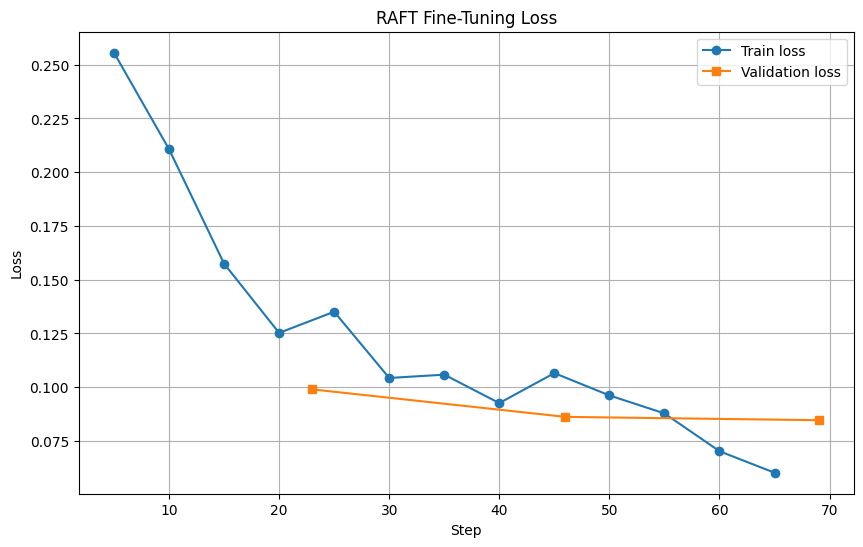

In [15]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [(x.get("step"), x["loss"]) for x in history if "loss" in x and "eval_loss" not in x]
eval_points = [(x.get("step"), x["eval_loss"]) for x in history if "eval_loss" in x]

plt.figure(figsize=(10, 6))
if train_points:
    plt.plot([x[0] for x in train_points], [x[1] for x in train_points], marker="o", label="Train loss")
if eval_points:
    plt.plot([x[0] for x in eval_points], [x[1] for x in eval_points], marker="s", label="Validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("RAFT Fine-Tuning Loss")
plt.grid(True)
plt.legend()
plt.show()

## 15. Simpan adapter dan model merged opsional

In [16]:
model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print("LoRA adapter disimpan:", ADAPTER_DIR)

if SAVE_MERGED_16BIT:
    model.save_pretrained_merged(
        str(MERGED_DIR),
        tokenizer,
        save_method="merged_16bit",
    )
    print("Merged 16-bit disimpan:", MERGED_DIR)
else:
    print("Merged model tidak dibuat (SAVE_MERGED_16BIT=False).")

Unsloth: Restored added_tokens_decoder metadata in /workspace/model/raft_unsloth_v8/lora_adapter/tokenizer_config.json.


LoRA adapter disimpan: /workspace/model/raft_unsloth_v8/lora_adapter
Merged model tidak dibuat (SAVE_MERGED_16BIT=False).


## 16. Evaluasi model setelah fine-tuning

In [17]:
FastLanguageModel.for_inference(model)

finetuned_open_df = evaluate_model("finetuned", mode="open_book")
finetuned_closed_df = None
if RUN_CLOSED_BOOK_EVAL:
    finetuned_closed_df = evaluate_model("finetuned", mode="closed_book")

Evaluasi finetuned/open_book:   0%|          | 0/41 [00:00<?, ?it/s]Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_util


finetuned / open_book


,exact_match,token_f1,rouge_l_f1,retrieval_gt_coverage
mean,0.097561,0.617104,0.554419,0.667794


Disimpan ke: /workspace/model/raft_unsloth_v8/evaluation/finetuned_open_book_predictions.jsonl


## 17. Perbandingan baseline vs fine-tuned

In [18]:
def compare_runs(before_df, after_df, mode):
    if before_df is None:
        print(f"Baseline {mode} tidak tersedia.")
        return None

    metric_columns = ["exact_match", "token_f1", "rouge_l_f1", "retrieval_gt_coverage"]
    before = before_df.set_index("index")
    after = after_df.set_index("index")

    rows = []
    for metric in metric_columns:
        before_mean = float(before[metric].mean())
        after_mean = float(after[metric].mean())
        rows.append({
            "mode": mode,
            "metric": metric,
            "baseline": before_mean,
            "finetuned": after_mean,
            "delta": after_mean - before_mean,
        })

    summary = pd.DataFrame(rows)
    display(summary)
    summary.to_csv(RESULTS_DIR / f"comparison_{mode}.csv", index=False)

    detail = pd.DataFrame({
        "question": after["question"],
        "ground_truth": after["ground_truth"],
        "baseline_prediction": before["prediction"],
        "finetuned_prediction": after["prediction"],
        "baseline_token_f1": before["token_f1"],
        "finetuned_token_f1": after["token_f1"],
        "delta_token_f1": after["token_f1"] - before["token_f1"],
    }).reset_index(drop=True)
    detail.to_csv(RESULTS_DIR / f"comparison_details_{mode}.csv", index=False)
    return summary, detail


open_comparison = compare_runs(baseline_open_df, finetuned_open_df, "open_book")
if RUN_CLOSED_BOOK_EVAL:
    closed_comparison = compare_runs(baseline_closed_df, finetuned_closed_df, "closed_book")

,mode,metric,baseline,finetuned,delta
0,open_book,exact_match,0.000000,0.097561,0.097561
1,open_book,token_f1,0.593964,0.617104,0.023139
2,open_book,rouge_l_f1,0.532296,0.554419,0.022123
3,open_book,retrieval_gt_coverage,0.667794,0.667794,0.000000


## 18. Lihat contoh hasil terbaik dan terburuk

In [19]:
if baseline_open_df is not None:
    comparison_view = finetuned_open_df[[
        "question", "ground_truth", "prediction", "token_f1", "rouge_l_f1", "retrieval_gt_coverage"
    ]].copy()
    comparison_view["baseline_token_f1"] = baseline_open_df["token_f1"].values
    comparison_view["delta_token_f1"] = comparison_view["token_f1"] - comparison_view["baseline_token_f1"]

    print("Peningkatan terbesar:")
    display(comparison_view.sort_values("delta_token_f1", ascending=False).head(5))
    print("Penurunan/hasil terlemah:")
    display(comparison_view.sort_values("delta_token_f1", ascending=True).head(5))
else:
    display(finetuned_open_df.sort_values("token_f1", ascending=True).head(10))

Peningkatan terbesar:


,question,ground_truth,prediction,token_f1,rouge_l_f1,retrieval_gt_coverage,baseline_token_f1,delta_token_f1
33,"Apa yang dimaksud dengan ""keterlambatan pembay...",Berdasarkan Pasal 4 ayat (3) Peraturan Desa Ci...,Keterlambatan pembayaran iuran dalam Peraturan...,0.681319,0.571429,0.777778,0.135593,0.545725
10,Siapa aja sih yang harus bayar pungutan desa?,Yang wajib membayar pungutan desa adalah setia...,Orang atau badan/lembaga yang telah memperoleh...,0.845070,0.535211,0.647059,0.509091,0.335980
11,"Kalau lembaga mau minta pelayanan dari desa, s...",Apabila pelayanan diberikan kepada badan atau ...,Lembaga yang meminta pelayanan dari desa harus...,0.666667,0.416667,0.909091,0.451613,0.215054
9,Apa definisi pungutan desa menurut Peraturan D...,Pungutan desa adalah pembayaran kepada pemerin...,Pungutan desa adalah pembayaran kepada pemerin...,1.000000,1.000000,1.000000,0.816327,0.183673
0,Sebutkan semua unsur masyarakat yang terdiri d...,Unsur masyarakat yang terdiri dari tokoh dan p...,Unsur masyarakat yang terdiri dari tokoh dan p...,1.000000,1.000000,0.954545,0.842975,0.157025


Penurunan/hasil terlemah:


,question,ground_truth,prediction,token_f1,rouge_l_f1,retrieval_gt_coverage,baseline_token_f1,delta_token_f1
36,"Kalau ada kegiatan sosial di desa, seperti ban...",Berdasarkan Pasal 8 Peraturan Desa Cipedes No....,Informasi tidak ditemukan pada dokumen yang di...,0.067797,0.067797,0.142857,0.327273,-0.259476
29,Apa yang dimaksud dengan badan permusyawaratan...,Berdasarkan Pasal 1 angka 3 Peraturan Desa Cip...,Badan permusyawaratan desa (BPD) adalah wakil ...,0.317460,0.317460,0.333333,0.564706,-0.247246
28,Apa saja wewenang Badan Permusyawaratan Desa (...,Berdasarkan Pasal 4 Peraturan Desa Cipedes No....,Wewenang Badan Permusyawaratan Desa (BPD) menu...,0.244898,0.195918,0.233333,0.373333,-0.128435
14,Apa yang menjadi dasar pemberian pengurangan a...,Dasar pemberian pengurangan atau pembebasan pu...,Dasar pemberian pengurangan atau pembebasan pu...,0.723404,0.723404,0.900000,0.818182,-0.094778
23,Apa saja langkah-langkah yang harus dilakukan ...,Berdasarkan Pasal 11 ayat (4) Peraturan Desa C...,Langkah-langkah yang harus dilakukan oleh BPSP...,0.731343,0.656716,0.956522,0.813187,-0.081844


## Interpretasi hasil

- **Open-book Token F1 / ROUGE-L meningkat:** model lebih baik menggunakan dokumen hasil retrieval dan mengabaikan distraktor.
- **Closed-book meningkat:** sebagian pengetahuan domain terserap ke adapter LoRA.
- **Retrieval coverage rendah:** masalah utama ada pada retriever/korpus, bukan semata-mata model.
- **Training loss turun tetapi test tidak naik:** periksa kualitas label, retrieval, overfitting, dan kemiripan train–validation.
- **Exact match rendah tetapi F1 tinggi:** jawaban mungkin benar secara isi tetapi berbeda gaya kalimat.

Untuk eksperimen yang lebih kuat, buat data tes baru yang pertanyaannya tidak identik/parafrasa dekat dengan data fine-tuning, tetapi jawabannya tetap tersedia di korpus dokumen domain.